Precio Spot actual de SPY: $679.46


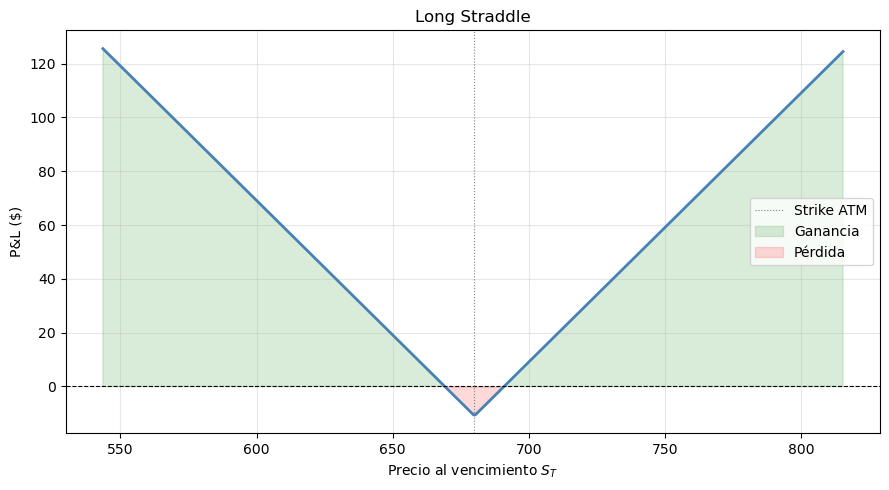

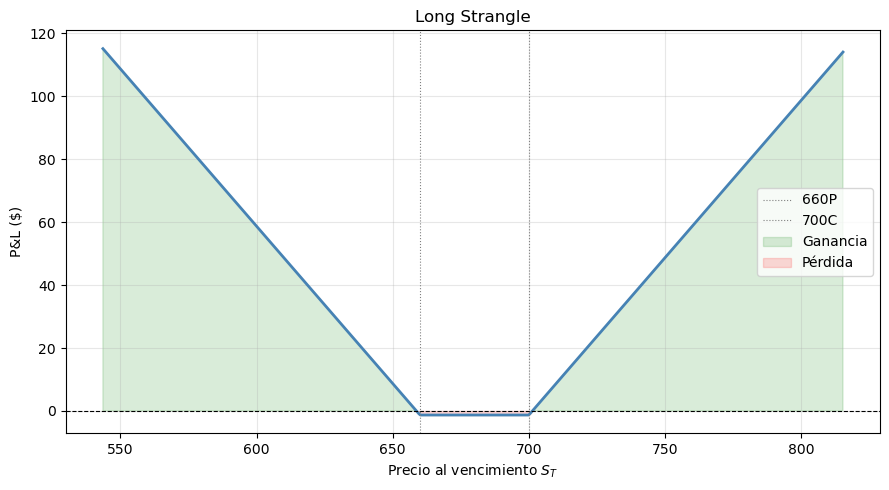

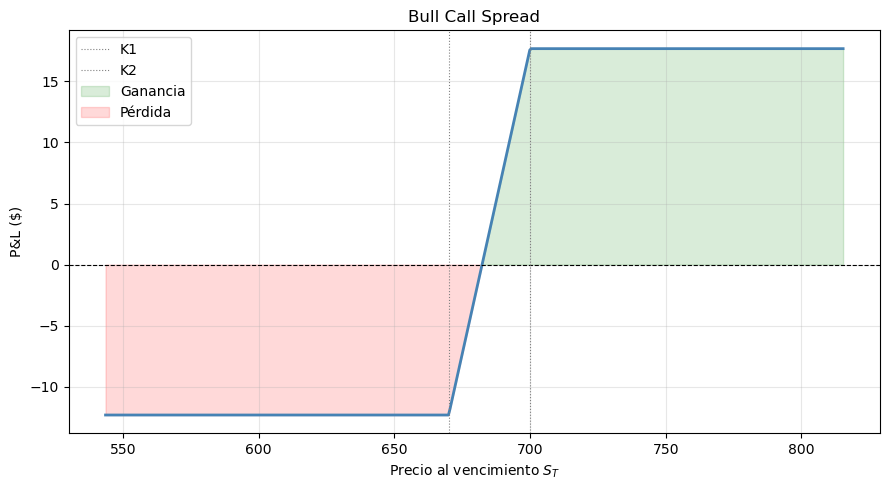

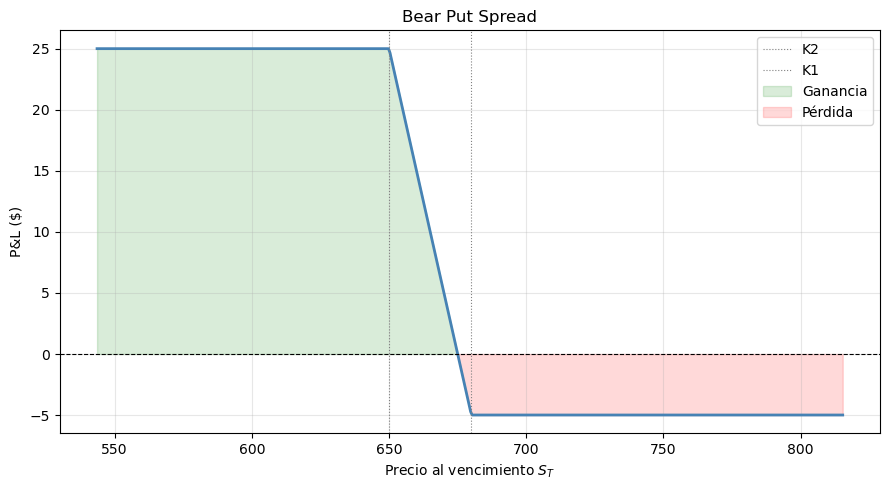


TABLA RESUMEN DE ESTRATEGIAS (Diferenciales Reales)
      Estrategia  Costo/Prima Neta Ganancia Máx  Pérdida Máx  Break-even(s)
   Long Straddle            10.880     Infinita      -10.880 669.12, 690.88
   Long Strangle             1.280     Infinita       -1.280 658.72, 701.28
Bull Call Spread            12.315       17.685      -12.315        682.315
 Bear Put Spread             4.995       25.005       -4.995        675.005


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de datos dinámicos
ticker = "SPY"
vencimiento = "2026-04-17"
spy = yf.Ticker(ticker)

# Obtener precio spot actual
s0 = spy.history(period="1d")['Close'].iloc[-1]
print(f"Precio Spot actual de {ticker}: ${s0:.2f}")

# Obtener cadenas de opciones
opt = spy.option_chain(vencimiento)
calls = opt.calls
puts = opt.puts

# Función auxiliar para obtener el precio mid (promedio Bid/Ask)
def get_mid_price(df, strike):
    row = df[df['strike'] == strike]
    if not row.empty:
        return (row['bid'].iloc[0] + row['ask'].iloc[0]) / 2
    return None

# 2. Funciones proporcionadas por el usuario
def payoff_estrategia(S_range, legs):
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
    return total

def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8, linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red', label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3. Definición y Ejecución de Estrategias
S_range = np.linspace(s0 * 0.8, s0 * 1.2, 500)
resumen_data = []

# --- LONG STRADDLE (Strike ATM) ---
k_straddle = round(s0 / 5) * 5  # Strike más cercano
c_straddle = get_mid_price(calls, k_straddle)
p_straddle = get_mid_price(puts, k_straddle)
legs_straddle = [
    {'tipo': 'call', 'K': k_straddle, 'prima': c_straddle, 'posicion': 1},
    {'tipo': 'put',  'K': k_straddle, 'prima': p_straddle, 'posicion': 1}
]
pnl_straddle = payoff_estrategia(S_range, legs_straddle)
costo_straddle = c_straddle + p_straddle
resumen_data.append(['Long Straddle', costo_straddle, 'Infinita', -costo_straddle, f"{k_straddle-costo_straddle:.2f}, {k_straddle+costo_straddle:.2f}"])

k_call_strangle, k_put_strangle = 700, 660
c_strangle = get_mid_price(calls, k_call_strangle)
p_strangle = get_mid_price(puts, k_put_strangle)
legs_strangle = [
    {'tipo': 'call', 'K': k_call_strangle, 'prima': c_strangle, 'posicion': 1},
    {'tipo': 'put',  'K': k_put_strangle, 'prima': p_strangle, 'posicion': 1}
]
pnl_strangle = payoff_estrategia(S_range, legs_strangle)
costo_strangle = c_strangle + p_strangle
resumen_data.append(['Long Strangle', costo_strangle, 'Infinita', -costo_strangle, f"{k_put_strangle-costo_strangle:.2f}, {k_call_strangle+costo_strangle:.2f}"])

k1_bull, k2_bull = 670, 700
c1_bull = get_mid_price(calls, k1_bull)
c2_bull = get_mid_price(calls, k2_bull)
prima_bull = c1_bull - c2_bull
legs_bull = [
    {'tipo': 'call', 'K': k1_bull, 'prima': c1_bull, 'posicion': 1},
    {'tipo': 'call', 'K': k2_bull, 'prima': c2_bull, 'posicion': -1}
]
pnl_bull = payoff_estrategia(S_range, legs_bull)
resumen_data.append(['Bull Call Spread', prima_bull, (k2_bull-k1_bull)-prima_bull, -prima_bull, k1_bull+prima_bull])

k1_bear, k2_bear = 680, 650
p1_bear = get_mid_price(puts, k1_bear)
p2_bear = get_mid_price(puts, k2_bear)
prima_bear = p1_bear - p2_bear
legs_bear = [
    {'tipo': 'put', 'K': k1_bear, 'prima': p1_bear, 'posicion': 1},
    {'tipo': 'put', 'K': k2_bear, 'prima': p2_bear, 'posicion': -1}
]
pnl_bear = payoff_estrategia(S_range, legs_bear)
resumen_data.append(['Bear Put Spread', prima_bear, (k1_bear-k2_bear)-prima_bear, -prima_bear, k1_bear-prima_bear])

# 4. Generación de Payoff Diagrams
graficar_estrategia(S_range, pnl_straddle, 'Long Straddle', [(k_straddle, 'Strike ATM')])
graficar_estrategia(S_range, pnl_strangle, 'Long Strangle', [(k_put_strangle, '660P'), (k_call_strangle, '700C')])
graficar_estrategia(S_range, pnl_bull, 'Bull Call Spread', [(k1_bull, 'K1'), (k2_bull, 'K2')])
graficar_estrategia(S_range, pnl_bear, 'Bear Put Spread', [(k2_bear, 'K2'), (k1_bear, 'K1')])

# 5. Mostrar Tabla Resumen
df_resumen = pd.DataFrame(resumen_data, columns=['Estrategia', 'Costo/Prima Neta', 'Ganancia Máx', 'Pérdida Máx', 'Break-even(s)'])
print("\n" + "="*30)
print("TABLA RESUMEN DE ESTRATEGIAS (Diferenciales Reales)")
print("="*30)
print(df_resumen.to_string(index=False))